In [3]:
%matplotlib inline
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))



In [4]:
import importlib
import src.cascade
importlib.reload(src.cascade)

casc = src.cascade.run()
casc.round(4)

A_tfidf        {'val': (1430, 70), 'test_in': (2800, 70), 'test_idoos': (280, 70), 'test_oodoos': (1000, 70)}
B_minilm       {'val': (1430, 70), 'test_in': (2800, 70), 'test_idoos': (280, 70), 'test_oodoos': (1000, 70)}
C_distilbert   {'val': (1430, 70), 'test_in': (2800, 70), 'test_idoos': (280, 70), 'test_oodoos': (1000, 70)}


/Users/manalfatima/projects/banking-intent-router/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


median single-query latency: A=2.66 ms  B=37.65 ms

escalate%  esc_rate  coverage  acc_all  wrong_acc  latency_ms  rej_id  rej_ood
       0     0.000     1.000   0.8871     0.1129        2.66   0.007    0.127
      25     0.225     0.966   0.9107     0.0757       11.13   0.339    0.942
      50     0.474     0.961   0.9164     0.0679       20.50   0.393    0.962
      75     0.726     0.960   0.9200     0.0639       30.01   0.404    0.967
     100     1.000     0.960   0.9214     0.0621       40.29   0.407    0.969


,escalate_pct,tau,escalation_rate,coverage,acc_all,acc_on_accepted,wrong_and_accepted,mean_latency_ms,rejected_idoos,rejected_oodoos
0,0.0,4.4123,0.0000,1.0000,0.8871,0.8871,0.1129,2.6580,0.0071,0.127
1,2.5,4.7603,0.0236,0.9932,0.8929,0.8950,0.1043,3.5454,0.1107,0.734
2,5.0,4.8869,0.0432,0.9886,0.8946,0.8985,0.1004,4.2850,0.1571,0.814
3,7.5,5.0309,0.0714,0.9829,0.9000,0.9048,0.0936,5.3472,0.1964,0.860
4,10.0,5.1263,0.0918,0.9789,0.9011,0.9084,0.0896,6.1137,0.2321,0.883
5,12.5,5.2384,0.1150,0.9754,0.9039,0.9121,0.0857,6.9877,0.2607,0.908
6,15.0,5.3331,0.1314,0.9732,0.9057,0.9141,0.0836,7.6062,0.2750,0.918
7,17.5,5.4418,0.1546,0.9696,0.9082,0.9182,0.0793,8.4803,0.3000,0.925
8,20.0,5.5245,0.1739,0.9689,0.9086,0.9185,0.0789,9.2064,0.3071,0.931
9,22.5,5.6208,0.1950,0.9679,0.9107,0.9214,0.0761,9.9997,0.3286,0.940


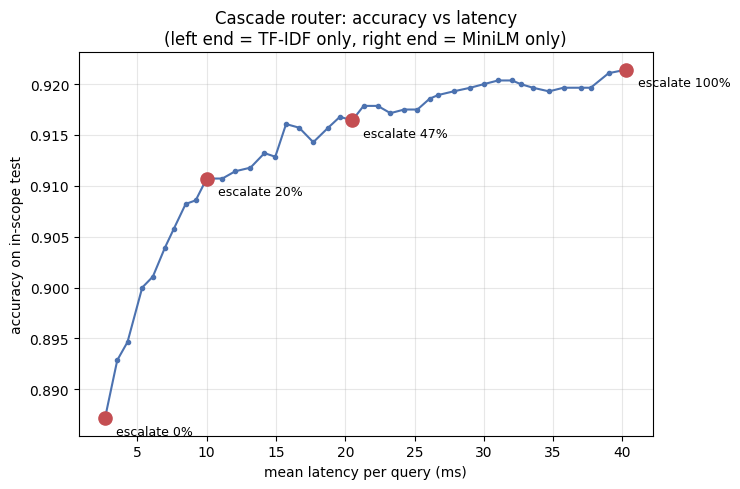

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
from src import config

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(casc["mean_latency_ms"], casc["acc_all"], marker="o", ms=3, color="#4c72b0")

for pct in [0, 22.5, 50, 100]:
    r = casc[casc["escalate_pct"] == pct].iloc[0]
    ax.scatter(r["mean_latency_ms"], r["acc_all"], s=90, zorder=5, color="#c44e52")
    ax.annotate(f"escalate {r['escalation_rate']:.0%}",
                (r["mean_latency_ms"], r["acc_all"]),
                textcoords="offset points", xytext=(8, -12), fontsize=9)

ax.set_xlabel("mean latency per query (ms)")
ax.set_ylabel("accuracy on in-scope test")
ax.set_title("Cascade router: accuracy vs latency\n(left end = TF-IDF only, right end = MiniLM only)")
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(config.FIGURES_DIR / "cascade.png", dpi=150)
plt.show()